In [1]:
import altair as alt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

path_datasets = "../datasets/"
# Load the dataset
df = pd.read_csv(path_datasets + "cilindros.csv")

# Display the first 5 rows
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print(df.info())

| Unnamed: 0   | Equipamento   | A     | B     | C     | D     | E     | Máximo   | Mínimo   |
|:-------------|:--------------|:------|:------|:------|:------|:------|:---------|:---------|
| IJ-135       | *             | 20.12 | 20.14 | 20.2  | 20.25 | 20.25 | 20.25    | 20.12    |
| IJ-151       | **            | 20.01 | 20.02 | 20.03 | 20.03 | 20.03 | 20.03    | 20.01    |
| IJ-152       | ***           | 20.01 | 20.03 | 20.03 | 20.04 | 20.05 | 20.05    | 20.01    |
| nan          | IJ-044        | 20.05 | 20.05 | 20.05 | 20.05 | 20.05 | 20.05    | 20.05    |
| nan          | IJ-046        | 20.06 | 20.07 | 20.1  | 20.11 | 20.15 | 20.15    | 20.06    |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   3 non-null      object
 1   Equipamento  28 non-null     object
 2   A            28 non-null     object
 3   B            28 non-nul

In [3]:
import altair as alt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Drop the `Unnamed: 0` column
df = df.drop("Unnamed: 0", axis=1)

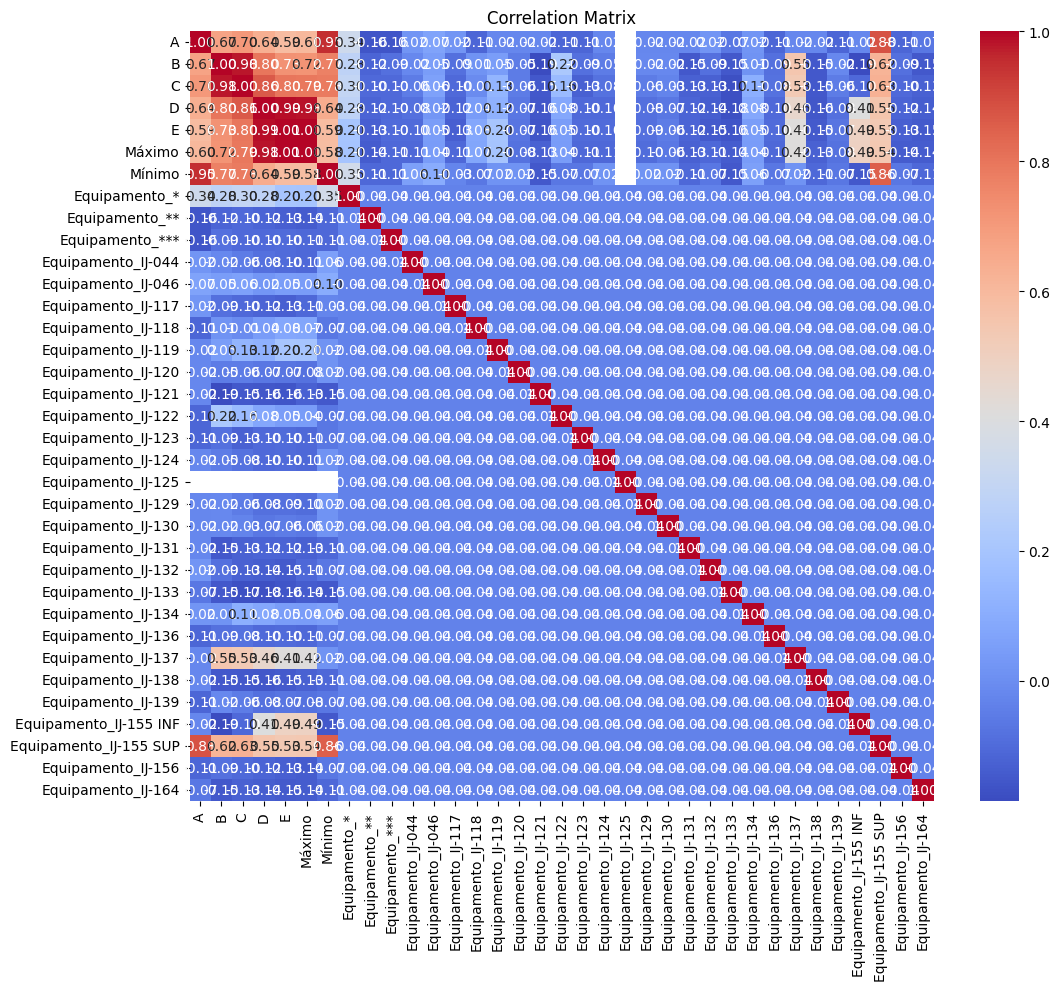

In [4]:
# Convert columns `A`, `B`, `C`, `D`, `E`, `Máximo`, and `Mínimo` to numeric
for col in ["A", "B", "C", "D", "E", "Máximo", "Mínimo"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# One-hot encode `Equipamento`
df = pd.get_dummies(df, columns=["Equipamento"])

# Calculate the correlation matrix
corr_matrix = df.corr()

# Get the column names
column_names = corr_matrix.columns.tolist()

# Plotting the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=column_names,
    yticklabels=column_names,
)
plt.title("Correlation Matrix")
plt.show()

In [5]:
# Display the correlation matrix
print(corr_matrix.to_markdown(numalign="left", stralign="left"))

# Prepare data for Altair heatmap
corr_matrix_melted = corr_matrix.reset_index().melt("index")
corr_matrix_melted = corr_matrix_melted.rename(
    columns={"index": "Variable 1", "variable": "Variable 2", "value": "Correlation"}
)

# Create the Altair heatmap
base = alt.Chart(corr_matrix_melted).encode(
    x="Variable 1",
    y="Variable 2",
    color=alt.Color("Correlation", scale=alt.Scale(range="diverging")),
    tooltip=["Variable 1", "Variable 2", "Correlation"],
)

heatmap = base.mark_rect()
text = heatmap.mark_text().encode(color=alt.value("black"), text="Correlation:Q")
chart = heatmap + text
chart = chart.properties(title="Correlation Matrix")

# Save the chart
chart.save("correlation_matrix_cilindros.json")
chart.save("correlation_matrix_cilindros.png")

|                        | A          | B          | C           | D          | E          | Máximo     | Mínimo     | Equipamento_*   | Equipamento_**   | Equipamento_***   | Equipamento_IJ-044   | Equipamento_IJ-046   | Equipamento_IJ-117   | Equipamento_IJ-118   | Equipamento_IJ-119   | Equipamento_IJ-120   | Equipamento_IJ-121   | Equipamento_IJ-122   | Equipamento_IJ-123   | Equipamento_IJ-124   | Equipamento_IJ-125   | Equipamento_IJ-129   | Equipamento_IJ-130   | Equipamento_IJ-131   | Equipamento_IJ-132   | Equipamento_IJ-133   | Equipamento_IJ-134   | Equipamento_IJ-136   | Equipamento_IJ-137   | Equipamento_IJ-138   | Equipamento_IJ-139   | Equipamento_IJ-155 INF   | Equipamento_IJ-155 SUP   | Equipamento_IJ-156   | Equipamento_IJ-164   |
|:-----------------------|:-----------|:-----------|:------------|:-----------|:-----------|:-----------|:-----------|:----------------|:-----------------|:------------------|:---------------------|:---------------------|:-------------------

## Análise da Matriz de Correlação

A matriz de correlação foi gerada e salva como uma imagem. A saída também inclui a matriz de correlação em formato de tabela.

### Observações sobre a Matriz de Correlação:

* A diagonal principal da matriz de correlação sempre é 1, pois mostra a correlação de cada variável consigo mesma.
* A matriz é simétrica em relação à diagonal principal, pois a correlação entre as variáveis X e Y é a mesma que entre Y e X.
* As variáveis com correlação próxima de 1 são consideradas altamente correlacionadas positivamente, enquanto as variáveis com correlação próxima de -1 são consideradas altamente correlacionadas negativamente. As variáveis com correlação próxima de 0 não são consideradas muito correlacionadas.
* Neste conjunto de dados específico, parece haver uma correlação positiva entre 'C' e 'D'.
* Também pode ser observada uma correlação negativa entre 'Equipamento_IJ-121' e 'B'.
* 'Equipamento_IJ-125' tem valores nulos, o que resulta em valores nulos para correlações.